In [27]:
import control as ct
import matplotlib.pyplot as plt
import math
import numpy as np
import cvxpy as cp
import networkx as ntx
from scipy.integrate import solve_ivp
import os
import copy
import random
from control_utils import levants
from IPython.display import clear_output

from control_utils.politopic_representation import *

# rng = np.random.default_rng()
rng_seed = 5

np.random.seed(rng_seed)
random.seed(rng_seed)

In [ ]:
# constants
mi = 1.0 # damping coeficient
coupling_factor = 1.0
eps = 1e-9 #
eta = 5 # decay rate

# simulation time
time = 20

# normal cases
z_i_interval = [[0, 25]]
zeta_i_interval = []

# hyperplanes
a_i = np.array([
    [1, -1, 0, 0],
    [0, 0, 1, -1]
])
b_i = np.array([5, 5, 10, 10]).reshape(4, 1)+1
bR_i = np.array([5, 5, 10, 10]).reshape(4, 1)

# Connections Graph construction
N = 6

E_half = [(1, 2), (1, 3), (1, 5), (1, 6), (3, 4)]
x0_systems = np.array([
     2,  1,
     3,  2,
    -1,  0,
     3, -2,
     0, -5,
    -2,  2,
])/2

x0_observer = np.zeros(x0_systems.shape) # TODO: possible this has to be close enough due to set E
x0_levants = np.zeros(5*N)

x0 = np.concat([x0_systems, x0_observer, x0_levants], axis=0)

G = ntx.Graph()
G.add_nodes_from(range(1, N+1))
G.add_edges_from(E_half)

dG = ntx.DiGraph(G)
dG.remove_edges_from(E_half)

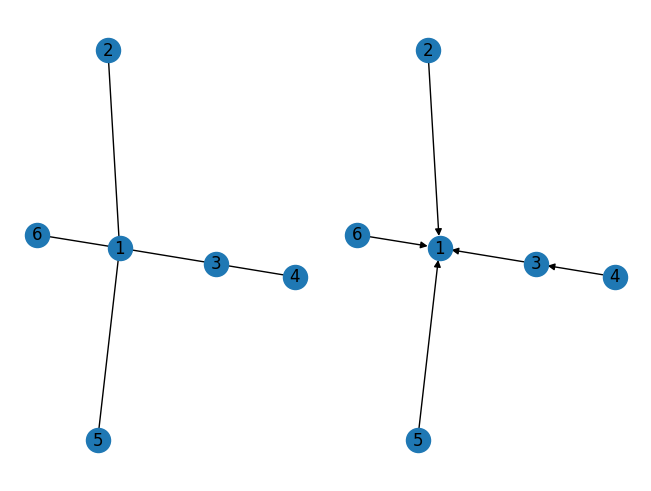

In [29]:
def plot_G():
    plt.figure(dpi=100, constrained_layout=True)
    plt.subplot(1, 2, 1)
    nodes_pos = ntx.spring_layout(G, pos={'0': (0, 0)}, iterations=500, seed=rng_seed)
    ntx.draw(G, pos=nodes_pos, with_labels=True)
    plt.subplot(1, 2, 2)
    ntx.draw(dG, pos=nodes_pos, with_labels=True)
    plt.show()

plot_G()

In [30]:
# kind of a constant in the way it is been built
a_cell = []
b_cell = []
bR_cell = []

for i in range(N):
    a_cell.append(a_i)
    b_cell.append(b_i)
    bR_cell.append(bR_i)

In [31]:
E_half = np.array(E_half)
if E_half.max() > N:
    raise Exception("Error in the connections set")

E_G = np.concat([E_half, np.flip(E_half, axis=1)], axis=0)
V_G = np.arange(start=1, stop=N+1)
A_G = np.zeros((N, N))
D_G = np.zeros((N, N))
L_G = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        is_in_array = np.any(np.all(E_G == [i+1, j+1], axis=1))

        if is_in_array:
            A_G[i, j] = 1

for i in range(N):
    D_G[i, i] = np.sum(A_G[i,:])

L_G = D_G - A_G

In [32]:
# generate combinations for multi-index -> j, k \in \mathbb{I}_{n_z} and l \in \mathbb{I}_{n_zeta}
n_z = len(z_i_interval)
n_zeta = len(zeta_i_interval)

interval_size = 2 # Just to make this information explict

j_perms, _ = permn(np.arange(interval_size), n_z)
k_perms, _ = permn(np.arange(interval_size), n_z)
l_perms, _ = permn(np.arange(interval_size), n_zeta)

In [33]:
def A_ijl(z: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [0, 1],
        [0, 0],
    ])

def C_ijl(z: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [1, 0]
    ]).reshape((1, 2))


In [34]:
A_cell = []
C_cell = []

for i in range(N):
    A_i_cell = []
    C_i_cell = []

    for j_p in j_perms:

        jl_perm = j_p

        A_ind = bin_perm_to_dec(jl_perm)
        C_ind = A_ind

        z = []
        for j in range(n_z):
            z.append(z_i_interval[j][jl_perm[j]])
        
        zeta = []
        for j in range(n_zeta):
            zeta.append(zeta_i_interval[j][jl_perm[n_z + j]])

        A_i_cell.append(A_ijl(z))
        C_i_cell.append(C_ijl(z))
    
    A_cell.append(A_i_cell)
    C_cell.append(C_i_cell)

In [35]:
j_perms_plus = perm_plus(j_perms)
k_perms_plus = perm_plus(k_perms)

In [36]:
def phi_z(F: np.ndarray, z: np.ndarray, b: np.ndarray): # TODO: move to a local utils under project UIO or to the LMIS definition
    '''
        ### The parameters are given from the expressions and are used to generate Lmis for Theorem 1 of Coutinho et al.
        R = { x \in RR^n : F@x <= b} \\
        phi(z) = min{ b.T@w: F.T@w = z, w \in RR^f >= 0 }
    '''

    w = cp.Variable((b.shape[0], 1))
    constrains = []

    constrains += [ w >= 0]
    
    constrains += [ F.T@w == z ]

    prob = cp.Problem(cp.Minimize(b.T@w), constraints=constrains)
    result = prob.solve(solver=cp.MOSEK, verbose=False)

    return result

nx = []
ny = []

for i in range(N):
    nx_i = A_cell[i][0].shape[0]
    ny_i = C_cell[i][0].shape[0]
    
    nx.append(nx_i)
    ny.append(ny_i)

P_trace = 0
P_cell = []
L_till_cell = []

for i in range(N): # TODO: MAYBE fix this L_till_cell having 16 elements instead of Perm(n_z) - quite possible actually as the Upsilon is actually l sums of jk
    P_i = cp.Variable((nx[i], nx[i]), symmetric=True)
    P_cell.append(P_i)

    L_till_i_cell = []
    for perm in k_perms:
        L_till_i = cp.Variable((nx[i], ny[i]))
        L_till_i_cell.append(L_till_i)
    
    L_till_cell.append(L_till_i_cell)

constrains = []

for i in range(N):

    P_trace += cp.trace(P_cell[i])
    constrains += [P_cell[i] >> eps] # the same as P > 0

    for m_index in j_perms_plus:
        for n_index in k_perms_plus:

            m_perms = multi_index_permutation(copy.deepcopy(m_index))
            n_perms = multi_index_permutation(copy.deepcopy(n_index))

            Upsilon_mnk_sum = 0
            for m_perm in m_perms:
                for n_perm in n_perms:
                    jl_perm = m_perm
                    
                    A_ind = bin_perm_to_dec(copy.deepcopy(jl_perm))
                    L_ind = bin_perm_to_dec(copy.deepcopy(n_perm))
                    C_ind = A_ind

                    M = P_cell[i]@A_cell[i][A_ind] - L_till_cell[i][L_ind]@C_cell[i][C_ind] + eta*P_cell[i]
                    Upsilon_mnk_sum += M + M.T
        
            constrains += [Upsilon_mnk_sum << -eps]
        
    for j in range(a_cell[i].T.shape[0]):
        aj = np.expand_dims(a_cell[i].T[j], axis=1)
        phi = phi_z(a_cell[i].T, aj, bR_cell[i])
        sj = 1/(b_cell[i][j] - phi) * aj

        M = cp.bmat([
            [np.eye(1), sj.T],
            [sj       , P_cell[i]],
        ])
        constrains += [ M >> 0 ] # >= breaks -> i know why but cannot remember right now


prob = cp.Problem(cp.Minimize(P_trace), constraints=constrains)
result = prob.solve(solver=cp.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Nov 14 03:09:58 PM: Your problem has 48 variables, 336 constraints, and 0 parameters.
(CVXPY) Nov 14 03:09:58 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Nov 14 03:09:58 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Nov 14 03:09:58 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Nov 14 03:09:58 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Nov 14 03:09:58 PM: Compiling problem (target solver=MOSEK).
(

<>:2: SyntaxWarning: invalid escape sequence '\i'
<>:2: SyntaxWarning: invalid escape sequence '\i'
C:\Users\luiza\AppData\Local\Temp\ipykernel_17892\3082952611.py:2: SyntaxWarning: invalid escape sequence '\i'
  '''


(CVXPY) Nov 14 03:09:58 PM: Finished problem compilation (took 1.190e-01 seconds).
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
(CVXPY) Nov 14 03:09:58 PM: Invoking solver MOSEK  to obtain a solution.


(CVXPY) Nov 14 03:09:58 PM: Problem
(CVXPY) Nov 14 03:09:58 PM:   Name                   :                 
(CVXPY) Nov 14 03:09:58 PM:   Objective sense        : maximize        
(CVXPY) Nov 14 03:09:58 PM:   Type                   : CONIC (conic optimization problem)
(CVXPY) Nov 14 03:09:58 PM:   Constraints            : 42              
(CVXPY) Nov 14 03:09:58 PM:   Affine conic cons.     : 0               
(CVXPY) Nov 14 03:09:58 PM:   Disjunctive cons.      : 0               
(CVXPY) Nov 14 03:09:58 PM:   Cones                  : 0               
(CVXPY) Nov 14 03:09:58 PM:   Scalar variabl

In [37]:
is_positive_defined = []
for i in range(N):
    i_is_positive_defined = True if all(np.linalg.eig(P_cell[i].value).eigenvalues > 0) else False
print(f'e.g.: P[1] = \n{P_cell[0].value}')
print(f"The solution is \'{prob.status}\', with Trace(P) = {result:.2f} and P is {"Positive Defined" if all(is_positive_defined) else "NOT Positive Defined"}")

e.g.: P[1] = 
[[100.00960541  -9.90294513]
 [ -9.90294513   1.98058902]]
The solution is 'optimal', with Trace(P) = 611.94 and P is Positive Defined


In [38]:
L_cell = []

for i in range(N):
    P_i_inv = np.linalg.inv(P_cell[i].value)

    L_till = []
    for j in range(len(L_till_cell[i])):
        # print(L_till_array[i].value)
        L_till.append(P_i_inv@L_till_cell[i][j].value)
    L_cell.append(L_till)

In [39]:
k = 0
A_cell[k], C_cell[k], L_cell[k]

([array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]])],
 [array([[1, 0]]), array([[1, 0]])],
 [array([[10.32148069],
         [52.10228373]]),
  array([[10.32148069],
         [52.10228373]])])

In [40]:
# simulação

def f_x(x_i, mi=1):
    return np.array([
        [x_i[1]],
        [-x_i[0] + mi*(1 - x_i[0]**2)*x_i[1]],
    ])

    return np.array([
        [x[1]],
        [-x[0] + mi*(1 - x[0]**2)*x[1]],
        [x[3]],
        [-x[2] + mi*(1 - x[2]**2)*x[3]]
    ])


def gd_x(i: int, n: int, N: int, x: np.ndarray, G: ntx.Graph) -> list[np.ndarray[float], np.ndarray[float]]: # check if this typing is correct
    """Calculates UIs

    Parameters
    ----------
    i : int
        Current system - 1 based index
    n : int
        Number of states
    N : int
        Number of subsystems
    x : np.ndarray
        All states
    G : ntx.Graph
        Graph of interconnections
    
    Returns
    ----------
    G*d(x), d(x) : np.ndarray[float], np.ndarray
    """

    # TODO: handle this differently
    # removing levants differentiations and observer
    # n = (x.shape[0] - 4) // (2*G.number_of_nodes())
    gd = np.zeros(n)
    gd_decoupled = []
    
    i_id = (i-1) * n
    x_i = x[i_id:i_id+n]
    
    # print(f"x: {x}, x_i[{i-1}]: {x_i}, i_id: {i_id}")

    for edge in G.edges(i):
        j = edge[1] - 1 # mapping from 1~N to 0~N-1
        j_id = j * n
        x_j = x[j_id:j_id+n]

        # affects only the second state
        # print(f"x_j[{j_id/2}]: {x_j}, x_i[{i-1}]: {x_i}")
        d = -math.tanh(x_j[1] - x_i[1])
        gd[1] += d

        # print(f"edge: {edge}, d: {d}")

        gd_decoupled.append(d)

    gd = gd.reshape((n, 1))
    gd_decoupled = np.array(gd_decoupled).reshape(len(gd_decoupled), 1)

    return gd, gd_decoupled


# def gd_x(x_i: np.ndarray, x_j_cell: list[np.ndarray], cp: float) -> np.ndarray[float]:
#     gd = np.zeros(x_i.shape)

#     for x_j in x_j_cell:
#         gd[1] += -cp*math.tanh(x_j[1] - x_i[1])

#     return gd.reshape((x_i.shape[0], 1))

#     return np.array([
#         [0],
#         [-cp*math.tanh(x[3] - x[1])],
#         [0],
#         [-cp*math.tanh(x[1] - x[3])]
#     ])

# def gd_x_decoupled(x_i: np.ndarray, x_j_cell: list[np.ndarray], cp: float) -> np.ndarray[float]:
#     gd = []

#     for x_j in x_j_cell:
#         gd_ij = -cp*math.tanh(x_j[1] - x_i[1])

#         gd.append(gd_ij)

#     return np.array(gd).reshape(len(gd), 1)

def h_x(x_i):
    return np.array([x_i[0]])

def G_i() -> np.ndarray:
    return np.array([
        [0],
        [-1] # TODO: fix with degree
    ]).reshape((2, 1))

# def g_ij(x_i, x_j):
#     return np.array([
#         [0],
#         [-1]
#     ]).reshape((2, 1))

# def Gamma_inv(x_i: np.ndarray, y_i: np.ndarray, x_j_cell: list[np.ndarray]): # has the lie derivative varing for each

#     Gamma = None
#     for j in range(len(x_j_cell)): # columns
#         Gamma_i = np.zeros(shape=(y_i.shape[0], 1))
#         Gamma_i[0] = -1 # HARDCODED

#         if Gamma is None:
#             Gamma = Gamma_i
#         else:
#             Gamma = np.concat([Gamma, Gamma_i], axis=1)

#     # print(Gamma)

#     return np.linalg.pinv(Gamma)

def Gamma_inv() -> np.ndarray:
    """Calculates Gamma_inv(x)

    Returns
    ----------
    Gamma_inv : np.ndarray
    """
    Gamma = G_i()[1]

    return np.array(1/Gamma)

def Q_x() -> np.ndarray:
    """Calculates Q(x)
    
    Returns
    ----------
    Q(x) : np.ndarray
    """
    g_i = G_i()
    gamma_inv = Gamma_inv()
    Q  = g_i@gamma_inv # TODO: check why i need to force this -1

    return np.expand_dims(Q, axis=1)

# def Q_x(x_i: np.ndarray, y_i: np.ndarray, x_j_cell: list[np.ndarray], i: int, t: float):
#     g_i = []
#     for j in range(len(x_j_cell)):
#         g_i.append(g_ij(x_i, x_j_cell[j]))
#     g_i = np.array(g_i).T.squeeze().reshape((2, -1))

#     G_i = Gamma_inv(x_i, y_i, x_j_cell)
#     Q  = g_i@G_i

#     # if t == 0.0:
#     #     print(f"syst: {i+1} \ng = {g_i} \nGamma = \n{G_i} \nQ = \n{Q}\n\n")

#     return Q

def Psi_x(x_i: np.ndarray):
    Psi = f_x(x_i)[1]
    Psi = np.array(Psi).reshape((len(Psi), 1))

    return Psi

# def Psi_x(x_i: np.ndarray, y_i: np.ndarray, x_j_cell: list[np.ndarray], mi: float):
#     Psi = lambda x: -x[0] + mi*(1 - x[0]**2)*x[1]

#     Psi_cell = []
#     Psi_cell.append(Psi(x_i))

#     # print(f"y_i: {y_i}, shape: {y_i.shape}")

#     # for j in range(y_i.shape[0]-1):
#     #     x_j = x_j_cell[j]
#     #     Psi_cell.append(Psi(x_j))
    
#     Psi_cell = np.array(Psi_cell).reshape((len(Psi_cell), 1))

#     return Psi_cell

# def Y_levants(xj_cell: list[list[np.ndarray, list[np.ndarray]]], cp: float):
#     Y_l = []

#     # print(f"xj: {xj_cell}, shape: {len(xj_cell)}")

#     for xj in xj_cell:
#         x_i = xj[0]
#         x_j_cell = xj[1]

#         Y_i = -x_i[0] + mi*(1 - x_i[0]**2)*x_i[1]
#         for x_j in x_j_cell:
#             Y_i += - cp*(math.tanh(x_j[1] - x_i[1]))
#         Y_l.append(Y_i)
#     Y_l = np.array(Y_l).reshape((len(xj_cell), 1))

#     # for x_i in x_i_cell:
#     #     Y_i = -x_i[0] + mi*(1 - x_i[0]**2)*x_i[1]
#     #     for x_j in x_j_cell:
#     #         Y_i += - cp*(math.tanh(x_j[2] - x_i[2]))
#     #     Y_l.append(Y_i)
#     # Y_l = np.array(Y_l).reshape((len(x_i_cell), 1))

#     return Y_l

def dot_Y_levants(y: np.ndarray[float], Y_levants: np.ndarray[float]) -> np.ndarray[float]:
    """Returns dot_Y_levants"""

    # z1 = y1 = x2
    # z2 = dot_y1 = dot_x2
    # Only necessary up to z2 but higher order helps improve quality 
    lambda_y1 = np.array([26, 14, 8, 4, 2]) # .38S

    n_y1 = lambda_y1.shape[0]
    id_y1 = 0

    z_y1 = Y_levants[id_y1:n_y1]
    y1 = y[0]

    dot_y1 = levants.differentiator(y1, z_y1, lambda_y1)

    return np.concat([dot_y1], axis=0)

def model(t: float, x: np.ndarray[float], nx: int, G: ntx.Graph, mi: float, dist_hist: list[list]):
    print(f"t={t}s")

    # TODO: ADAPT THIS
    xdot = np.zeros(shape=x.shape) # half are the real states and the other half is the observer
    xdot = np.expand_dims(xdot, axis=1)

    # nx = int(x.shape[0]/(2*N))
    N = G.number_of_nodes()

    x_i_cell = []
    x_hat_i_cell = []
    Y_levants_i_cell = []

    for i in range(N):
        id = i * nx
        id_hat = id + N*nx
        id_levants = id_hat + N*nx

        x_i_cell.append(x[id:id+nx])
        x_hat_i_cell.append(x[id_hat:id_hat+nx])
        Y_levants_i_cell.append(x[id_levants:id_levants+5])

    dist_hist[0].append(t)
    for i in range(N):
        id = i * nx
        id_hat = id + N*nx
        id_Y_levants = id_hat + N*nx

        x_i = x_i_cell[i]
        x_hat_i = x_hat_i_cell[i]
        Y_levants_i = Y_levants_i_cell[i]
        
        i_mapped = i + 1
        d_i, d_i_decoupled = gd_x(i_mapped, nx, N, x, G)
        
        # x_j_cell = []

        alpha_i = [np.array([x_i[0]**2])]

        # for a in range(A_G[i].shape[0]):
        #     if A_G[i][a] == 1:
        #         x_j_cell.append(x_i_cell[a])

        # missing levants differentiator
        # d_i = gd_x(x_i, x_j_cell, cp) # g*d - coupling
        # d_i_decoupled = gd_x_decoupled(x_i, x_j_cell, cp)

        #######
        # xj_cell = [[x_i, x_j_cell]]
        xdot[id:id+nx] = f_x(x_i, mi) + d_i
        y_i = h_x(x_i)
        y_i_hat = h_x(x_hat_i)

        Q = Q_x()
        Psi_hat = Psi_x(x_hat_i)

        Y = np.array([
            Y_levants_i[2] # levants differentiattor
            # xdot[id+1, 0] # exact value
        ])

        L = L_alpha(alpha_i, z_i_interval, k_perms, L_cell[i])

        d_hat_decoupled = Gamma_inv()@(Y - Psi_hat)

        delta = np.expand_dims(y_i - y_i_hat, axis=1)
        xdot[id_hat:id_hat+nx] = f_x(x_hat_i) + Q@(Y - Psi_hat) + L@delta # delta

        dot_Y = dot_Y_levants(h_x(x_hat_i.reshape(2, 1)), Y_levants_i)
        xdot[id_Y_levants:id_Y_levants+5] = dot_Y

        if len(dist_hist) < i + 2:
            dist_hist.append([[], [], []])

        # if i == 0 and t == 0:
        #     print(Gamma_inv(x_hat_i, y_i, x_j_cell))
        #     print(d_hat)
        #     print("***")
        #     print(d_i_decoupled)
        #     print(d_hat_decoupled)
        #     print("##########")
        
        dist_hist[i+1][0].append(d_i_decoupled)
        dist_hist[i+1][1].append(d_hat_decoupled)
        dist_hist[i+1][2].append(xdot[id:id+nx])
        # dist_hist[i+1][3].append(rd)

    return xdot.flatten()

In [41]:
# if x0.shape[0] != A_cell[0][0].shape[0]*2*N:
#     raise Exception("error in X0 array")

sim_time = (0, time)
dist_hist = [[]]

result = solve_ivp(model, sim_time, x0, args=(A_cell[0][0].shape[0], G, mi, dist_hist), method="RK45", dense_output=True)  # LSODA
clear_output(wait=False)

t = result.t
x = result.y

In [42]:
# Convert dist_hist to np array
dist_hist[0] = np.array(dist_hist[0])
for i in range(1, len(dist_hist)):
    for j in range(len(dist_hist[i])):
        dist_hist[i][j] = np.array(dist_hist[i][j])

In [43]:
dist_hist_filtered = []

# filter to only data matching with t values
# idx = np.searchsorted(dist_hist[0], t, side='left')
idx = np.searchsorted(dist_hist[0], t, side='right') - 1

dist_hist[0] = dist_hist[0][idx]
for i in range(1, len(dist_hist)):
    for j in range(len(dist_hist[i])):
        dist_hist[i][j] = dist_hist[i][j][idx]

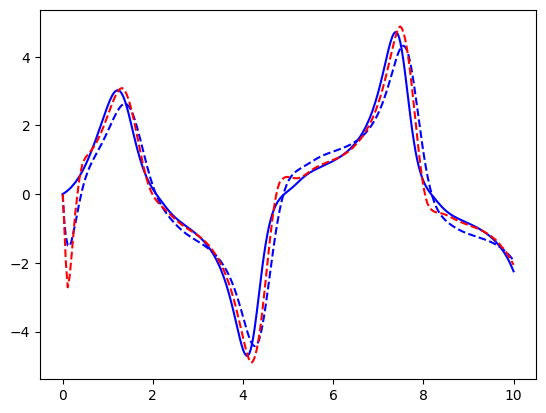

In [44]:
i = 2
x_i = 1
id = i * nx[0] + x_i
id_hat = id + N*nx[0]
id_Y_levants = id + 2*N*nx[0]

plt.figure()
plt.plot(t, x[id], 'b')
plt.plot(t, x[id_hat], 'b--')
# plt.plot(t, dist_hist[i+1][2][:, x_i-1], 'k--')
plt.plot(t, x[id_Y_levants], 'r--')
plt.show()

In [45]:
dG_adj_matrix = ntx.adjacency_matrix(dG)
G_adj_matrix = ntx.adjacency_matrix(G)

def rebuild_d(t_ind: int, i: int, n: int, x: np.ndarray, d_hist: list, d_rebuilt: list, G: ntx.Graph, dG: ntx.DiGraph) -> list[np.ndarray[float]]:
    """
    Parameters
    ----------
    t_ind : int
        Current time index
    i: int
        Current System - 0 based index
    """
    # print(f"i: {i}")
    
    
    has_anything_to_rebuid = np.sum(dG_adj_matrix[[i], :]) != 0
    if not has_anything_to_rebuid:
        return None

    # d_rebuilt_i = np.copy(d_hist[i+1][1][-1]) # [0: time; i+1: each subsystem][1: d_sum][last_time]
    d_rebuilt_i = d_hist[i+1][1][t_ind, 0] # [0: time; i+1: each subsystem][1: d_sum][last_time]

    has_only_one_connection = np.sum(G_adj_matrix[:, [i]]) == 1

    # print(f"i: {i} rebuilting with only one as: {has_only_one_connection}")

    if not has_only_one_connection:
        for j in range(N):
            if dG_adj_matrix[j, i] == 1:
                # print(f"{i}: d_rebuilt[{j}]: {d_rebuilt[j][-1]}")
                # TODO: handle signal
                # d_rebuilt += d_rebuilt[j+1][2][-1] # each rebuilt signal ha only one value in the list
                d_rebuilt_i += d_rebuilt[j][-1] # each rebuilt signal ha only one value in the list
    
    return d_rebuilt_i

In [46]:
d_rebuilt = []
for i in range(N):
    d_rebuilt.append([])

for t_i in range(len(dist_hist[0])):
    rebuild_order = [0, 1, 3, 4, 5, 2]
    for i in rebuild_order: # takes to much time - can be run outside after cleanning out t
        d_rebuilt_i = rebuild_d(t_i, i, nx, x, dist_hist, d_rebuilt, G, dG)
        d_rebuilt[i].append(d_rebuilt_i)

d_rebuilt = np.array(d_rebuilt)

In [47]:
def plot_graph(x, nx):
    plt.figure(dpi=150, constrained_layout=True)
    # plt.suptitle(f'{N}-Interconnected Oscilators', y=1.0)

    cols = 2
    rows = math.ceil(N/cols)

    for i in range(N):
        ind = i * nx
        ind_hat = ind + N*nx

        plt.subplot(rows, cols, i+1)
        plt.title(f"Oscilator {i+1}", fontsize=8)
        plt.scatter(x0[ind], x0[ind+1], s=30, facecolors='none', edgecolors='k') #, label=f'$\\mathbf{{x}}_{i+1}$')
        plt.plot(x[ind, :], x[ind+1, :], 'k') #, label=f'$\\mathbf{{x}}_{i+1}$')
        plt.plot(x[ind_hat, :], x[ind_hat+1, :], 'r--', linewidth=1) #, label=f'$\\mathbf{{\\hat{{x}}}}_{i+1}$')
        # plt.xlabel("$x_1$")
        # plt.ylabel("$x_2$")
        # plt.legend()
        
        plt.grid(which='both')
    
    legend = plt.figlegend([r'$\mathbf{x}_0$', r'$\mathbf{x}$', r'$\mathbf{\hat{x}}$'], loc = 'lower center', ncol = 3,  bbox_to_anchor=(0.5, -0.1))

    dir = os.path.join(os.curdir, f'.figures/')
    if not os.path.isdir(dir):
        os.mkdir(dir)

    plt.savefig(f".figures/dynamics_{N}", dpi=600, bbox_inches='tight', bbox_extra_artists=[legend])
    plt.show()

def plot_graph_dist(dist_hist):
    plt.figure(dpi=150, constrained_layout=True)

    cols = 2
    rows = math.ceil(N/cols)

    for i in range(N):
        ind = i * nx
        ind_hat = ind + N*nx

        plt.subplot(rows, cols, i+1)
        plt.title(f"Oscilator {i+1}", fontsize=8)

        plt.plot(t, np.sum(dist_hist[i+1][0], axis=1), 'k') #, label=f'$\\mathbf{{x}}_{i+1}$')
        plt.plot(t, -dist_hist[i+1][1], 'r--', linewidth=1) #, label=f'$\\mathbf{{\\hat{{x}}}}_{i+1}$')
        
        # plt.xlabel("$x_1$")
        # plt.ylabel("$x_2$")
        # plt.legend()
        
        # plt.ylim([-1, 1])
        plt.grid(which='both')
    
    # legend = plt.figlegend([r'$\mathbf{x}_0$', r'$\mathbf{x}$', r'$\mathbf{\hat{x}}$'], loc = 'lower center', ncol = 3,  bbox_to_anchor=(0.5, -0.1))

    # # dir = os.path.join(os.curdir, f'.figures/')
    # # if not os.path.isdir(dir):
    # #     os.mkdir(dir)

    # plt.savefig(f".figures/dynamics_{N}", dpi=600, bbox_inches='tight', bbox_extra_artists=[legend])
    plt.show()

def plot_graph_dist_ind(i, dist_hist, dist_rec, G, dG):
    plt.figure(dpi=150, constrained_layout=True)

    plt.title(f"Oscilator {i+1}", fontsize=8)

    color = ['k', 'b', 'r', 'g']
    hat_color = ['k--', 'b--', 'r--', 'g--']
    
    plt.plot(t, np.sum(dist_hist[i+1][0], axis=1), 'g', label=f'$\\Sigma$') # sum
    plt.plot(t, -np.sum(dist_hist[i+1][1], axis=1), 'g--', label=f'$\hat{{\\Sigma}}$') # sum

    for j, edge in zip(range(dist_hist[i+1][0][0].shape[0]), G.edges(i+1)):
        plt.plot(t, dist_hist[i+1][0][:, j], color[j], label=f'$\\mathbf{{d}}_{{{edge[0]}{edge[1]}}}$')
    
    for j, edge in zip(range(len(G.edges(i+1))), G.edges(i+1)):
        if edge not in dG.edges(i+1):
            plt.plot(t, dist_rec[edge[1]-1], hat_color[j], linewidth=1, label=f'$\\hat{{\\mathbf{{d}}}}_{{{edge[0]}{edge[1]}}}$')
        else:
            plt.plot(t, -dist_rec[i], hat_color[j], linewidth=1, label=f'$\\hat{{\\mathbf{{d}}}}_{{{edge[0]}{edge[1]}}}$')
    
    plt.xlabel("$t$")
    # plt.ylabel("$x$")
    plt.ylim([-2.5, 2.5])
    plt.legend()
    
    plt.grid(which='both')
    
    # legend = plt.figlegend([r'$\mathbf{x}_0$', r'$\mathbf{x}$', r'$\mathbf{\hat{x}}$'], loc = 'lower center', ncol = 3,  bbox_to_anchor=(0.5, -0.1))

    # # dir = os.path.join(os.curdir, f'.figures/')
    # # if not os.path.isdir(dir):
    # #     os.mkdir(dir)

    # plt.savefig(f".figures/dynamics_{N}", dpi=600, bbox_inches='tight', bbox_extra_artists=[legend])
    plt.show()

<>:73: SyntaxWarning: invalid escape sequence '\h'
<>:73: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_17892\1218958356.py:73: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(t, -np.sum(dist_hist[i+1][1], axis=1), 'g--', label=f'$\hat{{\\Sigma}}$') # sum


In [48]:
dG.edges(3)

OutEdgeDataView([(3, 1)])

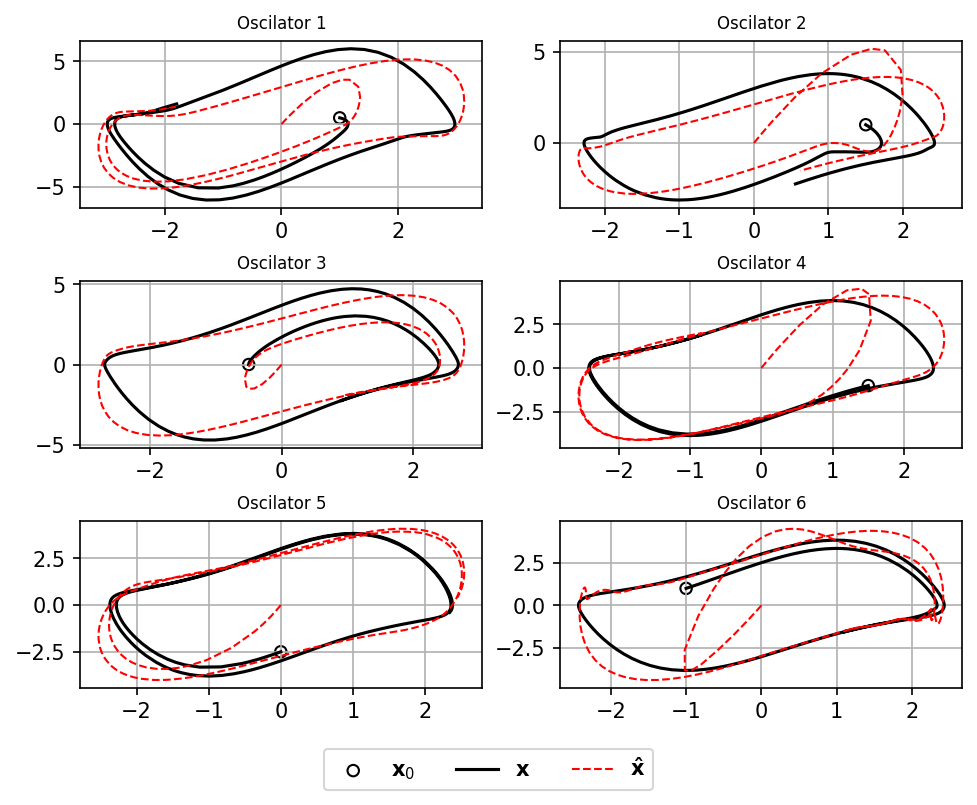

In [49]:
plot_graph(x, 2)

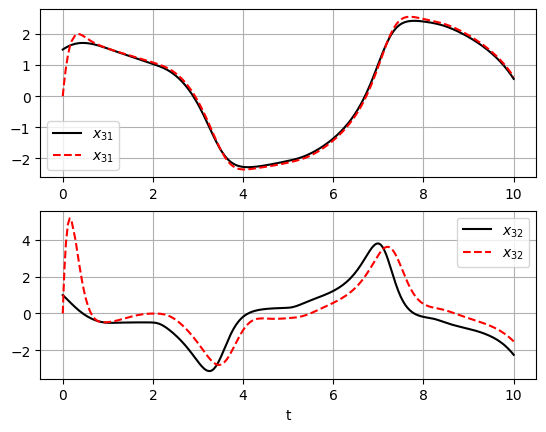

In [50]:
# Dynamics of one oscilator
i = 3
id = i - 1
id_hat = id + N*nx[0]
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(t, x[id, :], 'k', label=f'$x_{{{i}1}}$')
plt.plot(t, x[id_hat, :], 'r--', label=f'$x_{{{i}1}}$')
# plt.ylim([-.02, .02])
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(t, x[id+1, :], 'k',  label=f'$x_{{{i}2}}$')
plt.plot(t, x[id_hat+1, :], 'r--',  label=f'$x_{{{i}2}}$')
# plt.ylim([-.08, .08])
plt.xlabel('t')
plt.grid()
plt.legend()
plt.show()

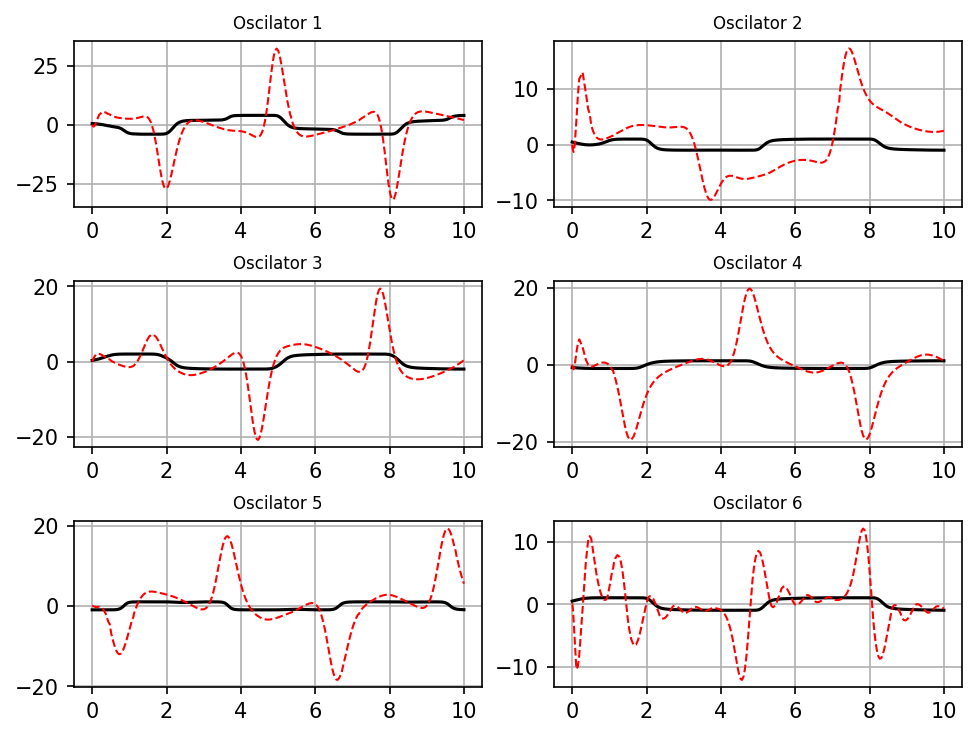

In [51]:
# Plot of dist sums and its estimation
plot_graph_dist(dist_hist)

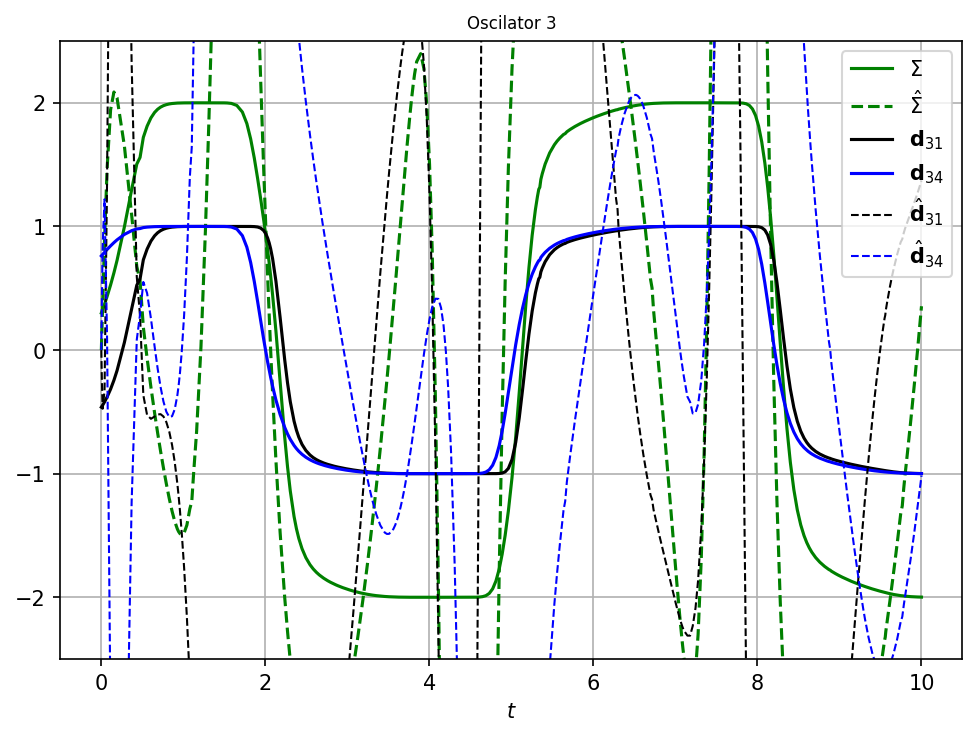

In [52]:
# Plot of each individual dist and its individual reconstruction
i = 2
plot_graph_dist_ind(i, dist_hist, d_rebuilt, G, dG)